# Lecture 10: Graph Mining
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Build and visualise graph structures with NetworkX
2. Compute degree, betweenness, and PageRank centrality
3. Detect communities using the Louvain algorithm
4. Apply graph analysis to a transaction network fraud scenario

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
print(f'NetworkX version: {nx.__version__}')
print('Ready.')

NetworkX version: 3.6.1
Ready.


## 10.1 Building a Graph

In [2]:
# Create a directed weighted transaction network
G = nx.DiGraph()

# Add accounts as nodes
accounts = ['ACC_001','ACC_002','ACC_003','ACC_004','ACC_005',
            'ACC_006','ACC_007','ACC_008','ACC_009','ACC_010']
G.add_nodes_from(accounts)

# Add transactions as directed weighted edges
transactions = [
    ('ACC_001','ACC_002', 5000), ('ACC_002','ACC_003', 4800),
    ('ACC_003','ACC_001', 4600), ('ACC_001','ACC_004', 2000),  # ring: 001->002->003->001
    ('ACC_005','ACC_006',15000), ('ACC_006','ACC_007',14500),
    ('ACC_007','ACC_005',14000), ('ACC_005','ACC_008', 1000),  # ring: 005->006->007->005
    ('ACC_009','ACC_001',  500), ('ACC_009','ACC_005',  800),
    ('ACC_010','ACC_002',  300), ('ACC_010','ACC_006',  400),
    ('ACC_004','ACC_009',  200), ('ACC_008','ACC_010',  150),
]
for src, tgt, amt in transactions:
    G.add_edge(src, tgt, weight=amt)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
print(f'\nIn-degree (top 3):')
for node, deg in sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:3]:
    print(f'  {node}: {deg}')

Nodes: 10
Edges: 14

In-degree (top 3):
  ACC_001: 2
  ACC_002: 2
  ACC_005: 2


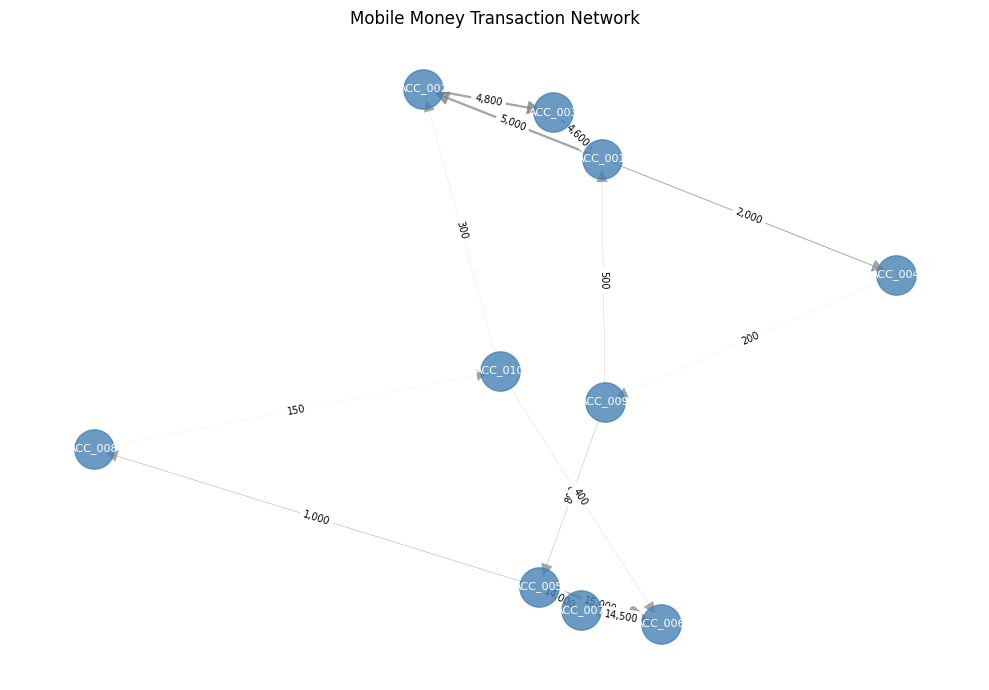

In [3]:
# Visualise the network
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=2)
weights = [G[u][v]['weight']/3000 for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='steelblue', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
nx.draw_networkx_edges(G, pos, width=weights, arrows=True,
                        edge_color='gray', arrowsize=20, alpha=0.7)
plabels = {(u,v): f'{d["weight"]:,}' for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=plabels, font_size=7)
plt.title('Mobile Money Transaction Network')
plt.axis('off')
plt.tight_layout()
plt.show()

## 10.2 Centrality Measures

In [4]:
# Degree centrality
dc = nx.degree_centrality(G)
print('Degree Centrality (top 5):')
for n, s in sorted(dc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {n}: {s:.4f}')

Degree Centrality (top 5):
  ACC_001: 0.4444
  ACC_005: 0.4444
  ACC_002: 0.3333
  ACC_006: 0.3333
  ACC_009: 0.3333


In [5]:
# Betweenness centrality
bc = nx.betweenness_centrality(G)
print('Betweenness Centrality (top 5):')
for n, s in sorted(bc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {n}: {s:.4f}')
print('\nHigh betweenness = bridge node connecting different parts of network')

Betweenness Centrality (top 5):
  ACC_005: 0.5000
  ACC_001: 0.4167
  ACC_002: 0.3194
  ACC_003: 0.3194
  ACC_004: 0.3194

High betweenness = bridge node connecting different parts of network


In [6]:
# PageRank
pr = nx.pagerank(G, alpha=0.85, weight='weight')
print('PageRank Scores (all nodes, sorted):')
for n, s in sorted(pr.items(), key=lambda x: x[1], reverse=True):
    print(f'  {n}: {s:.6f}')
print('\nHigh PageRank = receives value from other important nodes')

PageRank Scores (all nodes, sorted):
  ACC_005: 0.184467
  ACC_006: 0.179521
  ACC_007: 0.167591
  ACC_001: 0.115734
  ACC_003: 0.098649
  ACC_002: 0.098411
  ACC_009: 0.051641
  ACC_004: 0.043107
  ACC_010: 0.036080
  ACC_008: 0.024800

High PageRank = receives value from other important nodes


In [7]:
# Centrality summary table
cent_df = pd.DataFrame({
    'Degree': dc, 'Betweenness': bc, 'PageRank': pr
}).round(4)
cent_df['in_degree'] = dict(G.in_degree())
cent_df['out_degree'] = dict(G.out_degree())
cent_df.sort_values('PageRank', ascending=False)

,Degree,Betweenness,PageRank,in_degree,out_degree
ACC_005,0.4444,0.5000,0.1845,2,2
ACC_006,0.3333,0.1528,0.1795,2,1
ACC_007,0.2222,0.1528,0.1676,1,1
ACC_001,0.4444,0.4167,0.1157,2,2
ACC_003,0.2222,0.3194,0.0986,1,1
ACC_002,0.3333,0.3194,0.0984,2,1
ACC_009,0.3333,0.3194,0.0516,1,2
ACC_004,0.2222,0.3194,0.0431,1,1
ACC_010,0.3333,0.3194,0.0361,1,2
ACC_008,0.2222,0.3194,0.0248,1,1


## 10.3 Cycle Detection — Finding Suspicious Rings

In [8]:
# Find all simple cycles (closed loops of transactions)
cycles = list(nx.simple_cycles(G))
print(f'Number of cycles detected: {len(cycles)}')
for c in cycles:
    total_value = sum(G[c[i]][c[(i+1)%len(c)]]['weight'] for i in range(len(c)))
    print(f'  Cycle: {" -> ".join(c)} -> {c[0]} | Total Value: KES {total_value:,}')

Number of cycles detected: 5
  Cycle: ACC_007 -> ACC_005 -> ACC_006 -> ACC_007 | Total Value: KES 43,500
  Cycle: ACC_007 -> ACC_005 -> ACC_008 -> ACC_010 -> ACC_006 -> ACC_007 | Total Value: KES 30,050
  Cycle: ACC_002 -> ACC_003 -> ACC_001 -> ACC_002 | Total Value: KES 14,400
  Cycle: ACC_002 -> ACC_003 -> ACC_001 -> ACC_004 -> ACC_009 -> ACC_005 -> ACC_008 -> ACC_010 -> ACC_002 | Total Value: KES 13,850
  Cycle: ACC_004 -> ACC_009 -> ACC_001 -> ACC_004 | Total Value: KES 2,700


## 10.4 Community Detection

In [9]:
# Convert to undirected for community detection
G_un = G.to_undirected()

try:
    from networkx.algorithms import community
    communities = community.louvain_communities(G_un, seed=42)
    print('Communities detected by Louvain algorithm:')
    for i, comm in enumerate(communities):
        print(f'  Community {i+1}: {sorted(comm)}')
except (ImportError, AttributeError):
    # Fallback: Girvan-Newman
    from networkx.algorithms.community import girvan_newman
    comp = girvan_newman(G_un)
    communities = next(comp)
    print('Communities detected by Girvan-Newman:')
    for i, comm in enumerate(communities):
        print(f'  Community {i+1}: {sorted(comm)}')

Communities detected by Louvain algorithm:
  Community 1: ['ACC_001', 'ACC_002', 'ACC_003', 'ACC_004', 'ACC_009', 'ACC_010']
  Community 2: ['ACC_005', 'ACC_006', 'ACC_007', 'ACC_008']


## 10.5 Fraud Indicators Summary

In [10]:
print('=== FRAUD ANALYSIS SUMMARY ===')
print(f'\n1. RING STRUCTURES: {len(cycles)} circular transaction pattern(s) detected')
for c in cycles:
    total = sum(G[c[i]][c[(i+1)%len(c)]]['weight'] for i in range(len(c)))
    print(f'   {" -> ".join(c)} -> {c[0]}: KES {total:,}')

high_bc = [(n,s) for n,s in bc.items() if s > 0.1]
print(f'\n2. BRIDGE NODES (high betweenness): {[n for n,s in high_bc]}')
print('   These accounts connect otherwise separate transaction clusters.')

high_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:3]
print(f'\n3. HIGH PAGERANK ACCOUNTS: {[n for n,s in high_pr]}')
print('   These accounts accumulate the most influence from incoming transactions.')

=== FRAUD ANALYSIS SUMMARY ===

1. RING STRUCTURES: 5 circular transaction pattern(s) detected
   ACC_007 -> ACC_005 -> ACC_006 -> ACC_007: KES 43,500
   ACC_007 -> ACC_005 -> ACC_008 -> ACC_010 -> ACC_006 -> ACC_007: KES 30,050
   ACC_002 -> ACC_003 -> ACC_001 -> ACC_002: KES 14,400
   ACC_002 -> ACC_003 -> ACC_001 -> ACC_004 -> ACC_009 -> ACC_005 -> ACC_008 -> ACC_010 -> ACC_002: KES 13,850
   ACC_004 -> ACC_009 -> ACC_001 -> ACC_004: KES 2,700

2. BRIDGE NODES (high betweenness): ['ACC_001', 'ACC_002', 'ACC_003', 'ACC_004', 'ACC_005', 'ACC_006', 'ACC_007', 'ACC_008', 'ACC_009', 'ACC_010']
   These accounts connect otherwise separate transaction clusters.

3. HIGH PAGERANK ACCOUNTS: ['ACC_005', 'ACC_006', 'ACC_007']
   These accounts accumulate the most influence from incoming transactions.


### Exercise

Using the transaction network G:

1. Add 3 new accounts (ACC_011, ACC_012, ACC_013) and create a new ring transaction pattern between them with values around KES 8,000 each.
2. Re-run the cycle detection. Does the new ring appear?
3. Re-compute betweenness centrality. Which accounts have increased betweenness after adding the new transactions?
4. Create a visualisation that colour-codes nodes by their community membership.

Detected Cycles:
['ACC_012', 'ACC_013', 'ACC_011']
['ACC_007', 'ACC_005', 'ACC_006']
['ACC_007', 'ACC_005', 'ACC_008', 'ACC_010', 'ACC_006']
['ACC_002', 'ACC_003', 'ACC_001']
['ACC_002', 'ACC_003', 'ACC_001', 'ACC_004', 'ACC_009', 'ACC_005', 'ACC_008', 'ACC_010']
['ACC_004', 'ACC_009', 'ACC_001']

New ring detected: True

Betweenness Centrality (After):
ACC_001 0.2196969696969697
ACC_002 0.19696969696969696
ACC_003 0.19696969696969696
ACC_004 0.2196969696969697
ACC_005 0.32575757575757575
ACC_006 0.06060606060606061
ACC_007 0.06060606060606061
ACC_008 0.32575757575757575
ACC_009 0.2196969696969697
ACC_010 0.32575757575757575
ACC_011 0.007575757575757576
ACC_012 0.007575757575757576
ACC_013 0.007575757575757576

Nodes with increased betweenness:


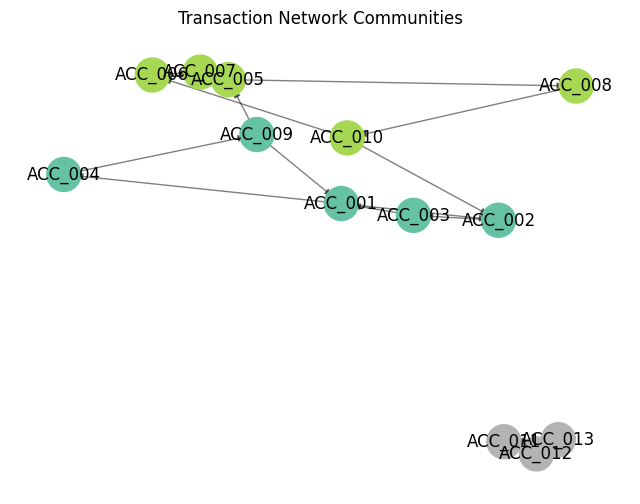

In [12]:
# Your code here
import networkx as nx
import matplotlib.pyplot as plt

# Store betweenness centrality BEFORE adding new nodes/edges
bc_before = nx.betweenness_centrality(G, weight='weight')

# ---------------------------------------------------
# 1. Add new nodes and ring transactions
# ---------------------------------------------------
new_edges = [
    ("ACC_011", "ACC_012", 8000),
    ("ACC_012", "ACC_013", 8200),
    ("ACC_013", "ACC_011", 7900)
]

G.add_nodes_from(["ACC_011", "ACC_012", "ACC_013"])
G.add_weighted_edges_from(new_edges)

# ---------------------------------------------------
# 2. Cycle detection
# ---------------------------------------------------
cycles = list(nx.simple_cycles(G))

print("Detected Cycles:")
for c in cycles:
    print(c)

# Check if new ring exists
new_ring = {"ACC_011", "ACC_012", "ACC_013"}
found_ring = any(new_ring.issubset(set(c)) for c in cycles)

print("\nNew ring detected:", found_ring)

# ---------------------------------------------------
# 3. Betweenness centrality before/after comparison
# ---------------------------------------------------
bc_after = nx.betweenness_centrality(G, weight='weight')

print("\nBetweenness Centrality (After):")
for node, score in bc_after.items():
    print(node, score)

# Identify increases
print("\nNodes with increased betweenness:")
for node in bc_after:
    before = bc_before.get(node, 0)
    after = bc_after[node]
    if after > before:
        print(f"{node}: {before:.4f} → {after:.4f}")

# ---------------------------------------------------
# 4. Community detection + visualization
# ---------------------------------------------------
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

# Map nodes to community index
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

node_colors = [community_map[node] for node in G.nodes()]

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2, node_size=600)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos)

plt.title("Transaction Network Communities")
plt.axis("off")
plt.show()

---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*